# Treinamento do modelo YOLO

Iremos treinar o modelo no dataset *aquarium*, que possui imagens de peixes, águas-vivas, pinguins, estrelas-do-mar e outros animais marinhos. O dataset é desafiador porque as imagens possuem variações relevantes de tonalidade.

In [ ]:
from ultralytics import YOLO

# Arquivo de configuração contendo informações sobre o dataset
dataset_yaml = "../data/aquarium/data.yaml"
# Modelo pré-treinado no dataset COCO, que contém 80 classes de objetos comuns. O modelo
# não possui conhecimento sobre as classes do dataset aquarium
model = YOLO("yolo26n.pt")

results = model.train(
    data=dataset_yaml, 
    epochs=2000, 
    # Termina o treinamento se a métrica de performance não melhorar por 100 épocas
    # A métrica usada é a mAP@0.5:0.95, que será explicada no próximo notebook
    patience=100,   
    batch=16,
    # Tamanho da imagem usada no treinamento
    imgsz=640,
    # Nome da pasta para salvar os resultados do treinamento
    project="aquarium_results",
    # Nome da subpasta para salvar os resultados do treinamento. Útil se forem feitos vários 
    # treinamentos para o mesmo projeto
    name="train",
    # Se True, sobrescreve os resultados do treinamento se a pasta já existir
    exist_ok=True,
    # Taxa de aprendizado inicial
    lr0=0.01,       
    # Fator de redução da taxa de aprendizado final. A taxa de aprendizado para cada época é 
    # calculada como lr = (1+(lrf-1)*epoch/total_epochs)*lr0
    lrf=0.01,       
    weight_decay=0.0005, 
    # Peso para a perda de caixa delimitadora
    box=7.5,  
    # Peso para a perda de classificação
    cls=0.5,  
    # O peso das classes é dado por (1.0 / ni) ^ cls_pw, onde ni é o número de objetos na classe i
    cls_pw=0.0, 
    # Peso para a perda de distribuição de caixa delimitadora (Distribution Focal Loss)
    dfl=1.5,    
    # Número máximo de detecções por imagem
    max_det=300
)

Adicionalmente, a função de treinamento possui diversos parâmetros relacionados com os aumentos de dados aplicados. Veja a tabela com todos os parâmetros em:

https://docs.ultralytics.com/modes/train#:~:text=Augmentation%20Settings%20and%20Hyperparameters

## Validação do modelo treinado

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
from ultralytics import YOLO

model = YOLO("runs/detect/aquarium_results/train/weights/best.pt")

metrics = model.val(
    data=dataset_yaml,
    imgsz=640,
    batch=16,
    device="cuda",  
    plots=False
)

Ultralytics 8.4.48 🚀 Python-3.14.4 torch-2.10.0 CUDA:0 (NVIDIA GeForce RTX 3080 Ti, 11908MiB)


YOLO26n summary (fused): 122 layers, 2,376,201 parameters, 0 gradients
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 9380.7±1973.3 MB/s, size: 566.5 KB)
val: Scanning /home/chcomin/Dropbox/ufscar/visao_computacional/repositorio/data/_aquarium/labels/val.cache... 127 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 127/127 88.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 5.6it/s 1.4s0.9ss
                   all        127        909       0.84      0.658      0.741      0.425
                  fish         63        459      0.803      0.702      0.775      0.405
             jellyfish          9        155      0.869      0.884      0.925      0.516
               penguin         17        104      0.751      0.683      0.696      0.301
                puffin         15         74      0.839      0.486      0.623      0.286
                 shark         28         57      0.779      0.596      0.679  

As métricas serão explicadas no próximo notebook. Mas em todos os casos, o ideal são valores próximos de 1.

## Predição em algumas imagens


0: 640x480 110 penguins, 1.2ms
1: 640x480 39 fishs, 1 penguin, 2 sharks, 1.2ms
2: 640x480 39 jellyfishs, 1.2ms
Speed: 1.1ms preprocess, 1.2ms inference, 0.1ms postprocess per image at shape (1, 3, 640, 480)


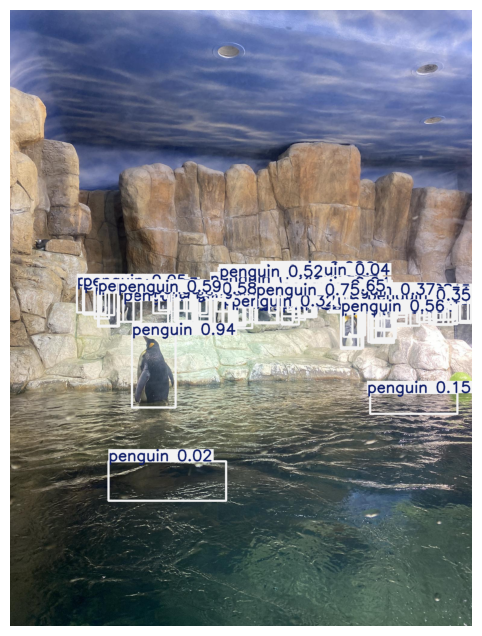

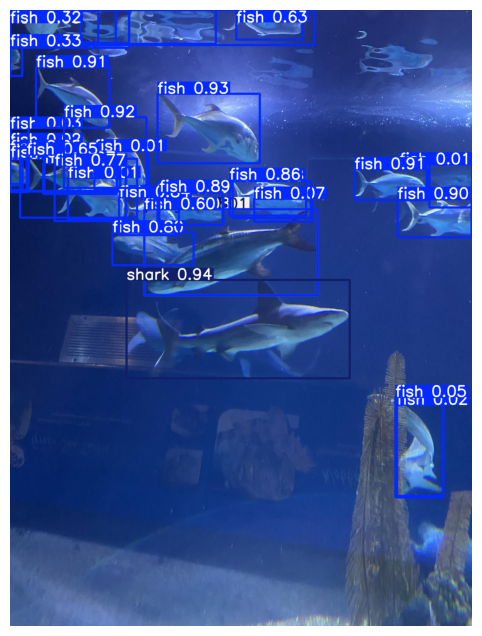

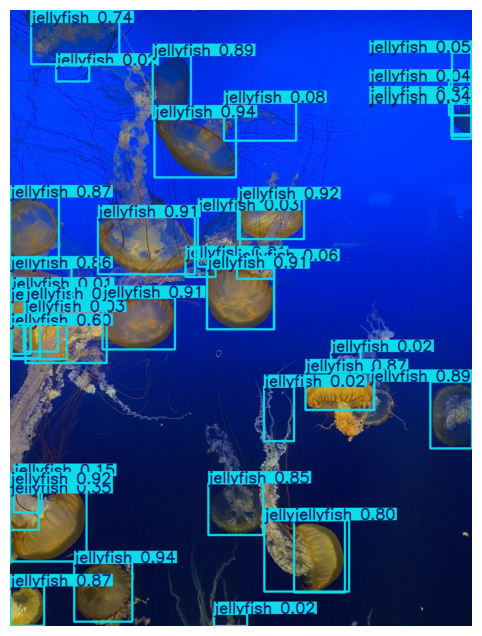

In [ ]:
img_names = [
    "IMG_2301_jpeg_jpg.rf.c46279b0217d12595c82eae1a7670d40",
    "IMG_2450_jpeg_jpg.rf.fd85d3b946a46d85c8de2350fac9f477",
    "IMG_2465_jpeg_jpg.rf.7b803fade1aee9b7df0ab1e0311af9d4"
]

imgs = []
for name in img_names:
    img = Image.open(f"../data/aquarium/images/test/{name}.jpg")
    imgs.append(img)


results = model.predict(
    source=imgs,
    conf=0.25,
    # O parâmetro iou é ignorado para o modelo YOLO26, que não utiliza NMS tradicional
    iou=0.7
)

for res in results:
    img_res = res.plot()
    img_res = img_res[:, :, ::-1]  # Converte BGR para RGB
    plt.figure(figsize=(8, 8))
    plt.imshow(img_res)
    plt.axis("off")


## Exportação do modelo para inferência

É possível exportar o modelo para ser utilizado em qualquer dispositivo (celulares, robôs, IoT, etc) sem que seja necessário Python ou Pytorch:

In [ ]:
from ultralytics import YOLO

model = YOLO("runs/detect/aquarium_results/tr/weights/best.pt")

model.export(
    # Formato de exportação do modelo. Alguns formatos populares são:
    # ONNX: Open Neural Network Exchange, um formato de modelo aberto que é amplamente suportado 
    #       por várias plataformas e frameworks.
    # TensorRT: Uma plataforma de inferência de alta performance desenvolvida pela NVIDIA, 
    #       otimizada para execução em GPUs NVIDIA.
    # OpenVINO: Uma ferramenta de otimização e inferência de modelo desenvolvida pela Intel, 
    #       projetada para acelerar a execução em hardware Intel.
    # CoreML: Um formato de modelo da Apple para execução em dispositivos iOS.
    format="onnx",
    # Tamanho da imagem de entrada para o modelo exportado. O modelo será otimizado para esse tamanho
    imgsz=640,
    # Permite que o modelo exportado suporte tamanhos diferentes de imagem, com possível perda de desempenho. 
    dynamic=False,
)